# 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

from src.features import FeatureSet, SIFT
from src.visualization import *
from src.matching import *
from src.anms import anms
from src.ransac import ransac_homography, RansacResult

In [ ]:
campus_0 = cv.imread("inputs/udesa_0.jpg")
campus_1 = cv.imread("inputs/udesa_1.jpg")
campus_2 = cv.imread("inputs/udesa_2.jpg")

cuadro_0 = cv.imread("inputs/cuadro_0.jpg")
cuadro_1 = cv.imread("inputs/cuadro_1.jpg")
cuadro_2 = cv.imread("inputs/cuadro_2.jpg")

campus_images = [campus_0, campus_1, campus_2]
cuadro_images = [cuadro_0, cuadro_1, cuadro_2]

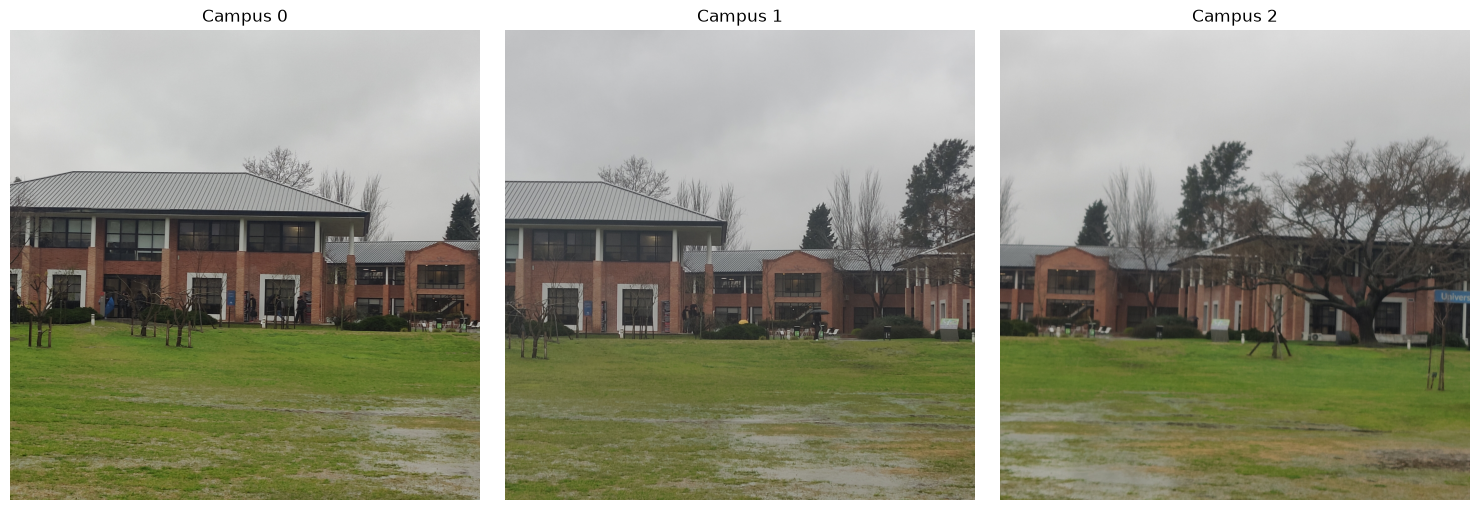

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, image) in enumerate(zip(axes, campus_images)):
    ax.imshow(image[:, :, ::-1], cmap="gray")
    ax.set_title(f"Campus {i}")
    ax.axis("off")

plt.tight_layout()

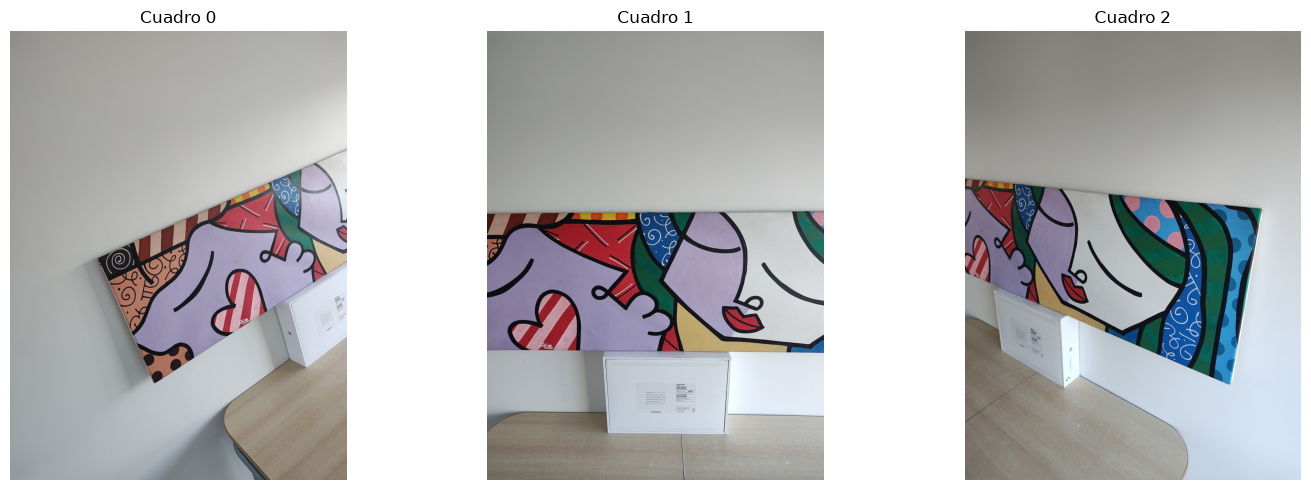

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, image) in enumerate(zip(axes, cuadro_images)):
    ax.imshow(image[:, :, ::-1], cmap="gray")
    ax.set_title(f"Cuadro {i}")
    ax.axis("off")

plt.tight_layout()

# 1. Preprocesamiento

In [6]:
sift = SIFT()

campus_keypoints = [
    sift.detect(image)
    for image in campus_images
]

for i, keypoints in enumerate(campus_keypoints):
    print(f"Campus {i}: {len(keypoints)} keypoints")

Campus 0: 22105 keypoints
Campus 1: 14851 keypoints
Campus 2: 5364 keypoints


In [7]:
MAX_KEYPOINTS = 2000
LOCAL_RADIUS = 10

campus_keypoints_anms = [
    anms(keypoints, MAX_KEYPOINTS, LOCAL_RADIUS)
    for keypoints in campus_keypoints
]

for i, keypoints in enumerate(campus_keypoints_anms):
    print(f"Campus {i}: {len(keypoints)} keypoints")

Campus 0: 2000 keypoints
Campus 1: 2000 keypoints
Campus 2: 2000 keypoints


In [8]:
campus_features = [
    sift.describe(image, keypoints)
    for image, keypoints in zip(
        campus_images,
        campus_keypoints_anms,
    )
]

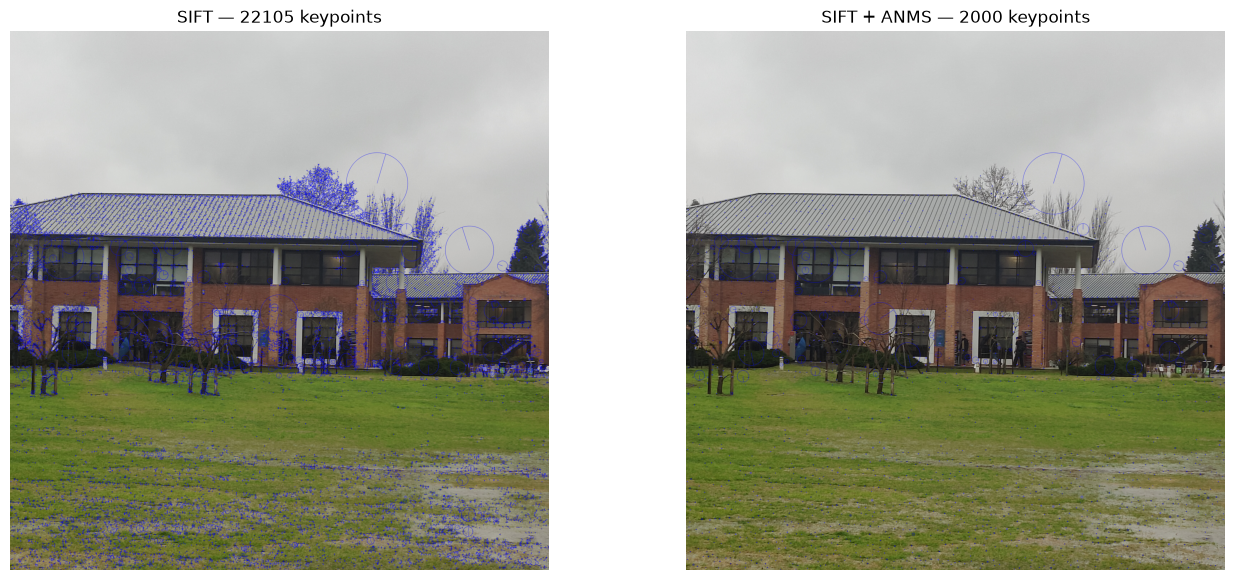

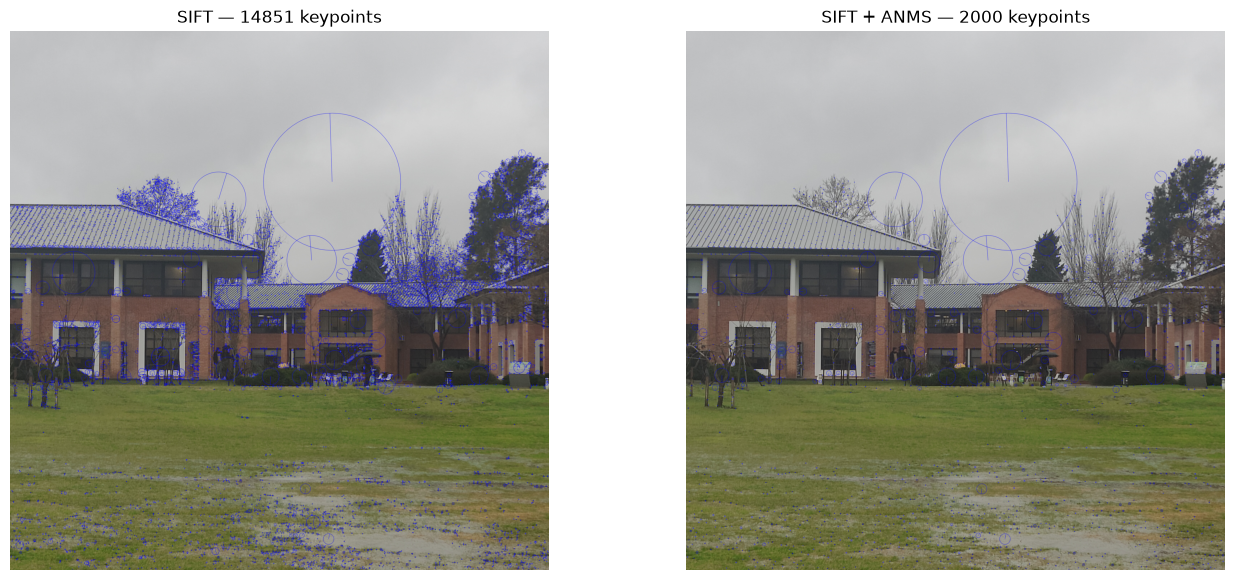

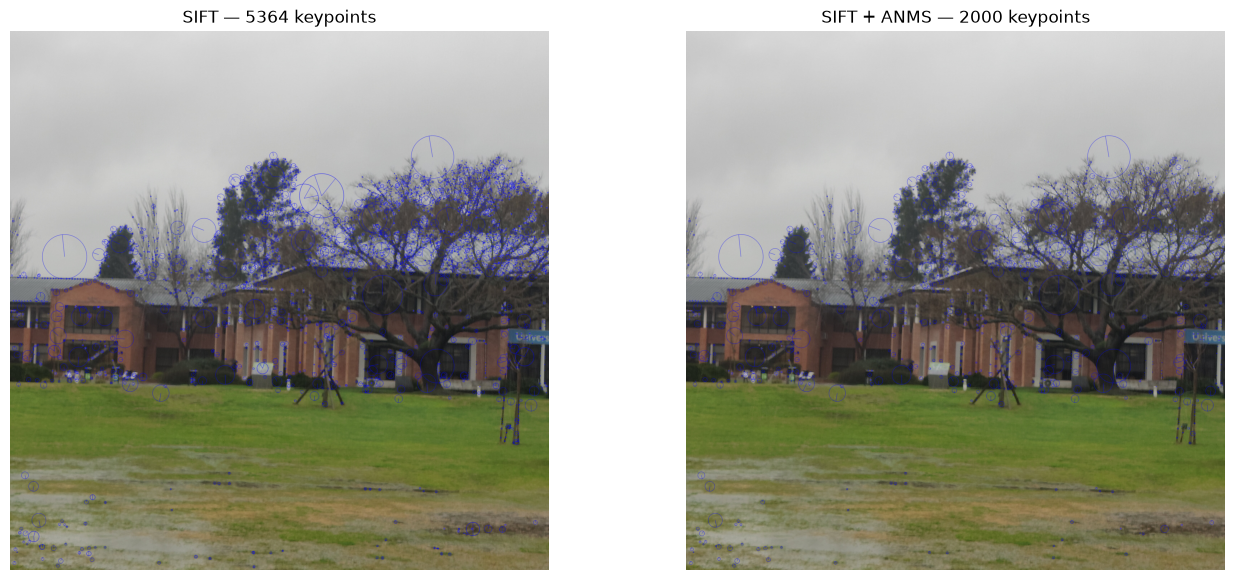

In [9]:
for i, image in enumerate(campus_images):
    plot_keypoint_comparison(
        image,
        campus_keypoints[i],
        campus_keypoints_anms[i],
        titles=("SIFT", "SIFT + ANMS"),
    )

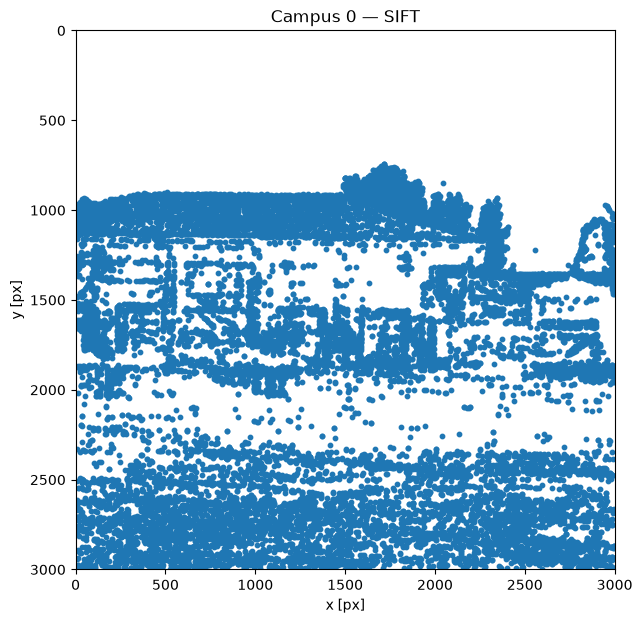

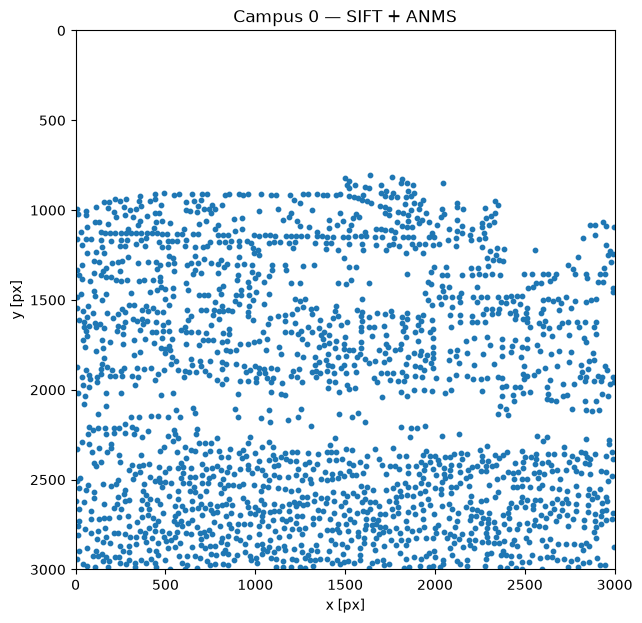

In [10]:
plot_keypoint_distribution(
    campus_0,
    campus_keypoints[0],
    title="Campus 0 — SIFT",
)

plot_keypoint_distribution(
    campus_0,
    campus_keypoints_anms[0],
    title="Campus 0 — SIFT + ANMS",
)

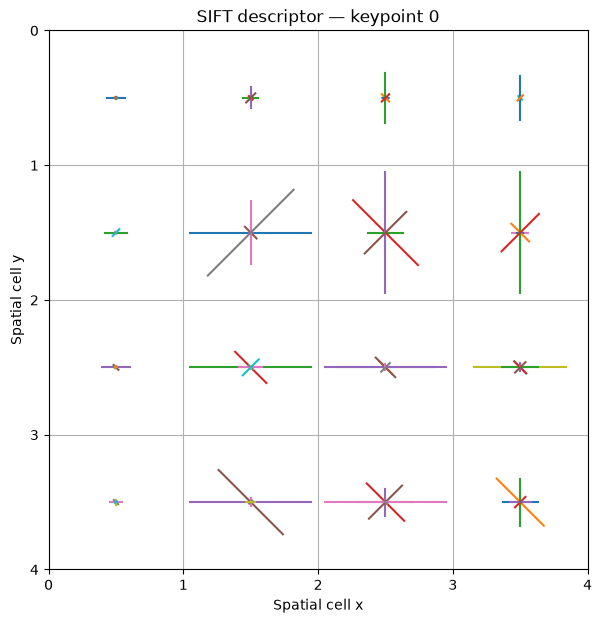

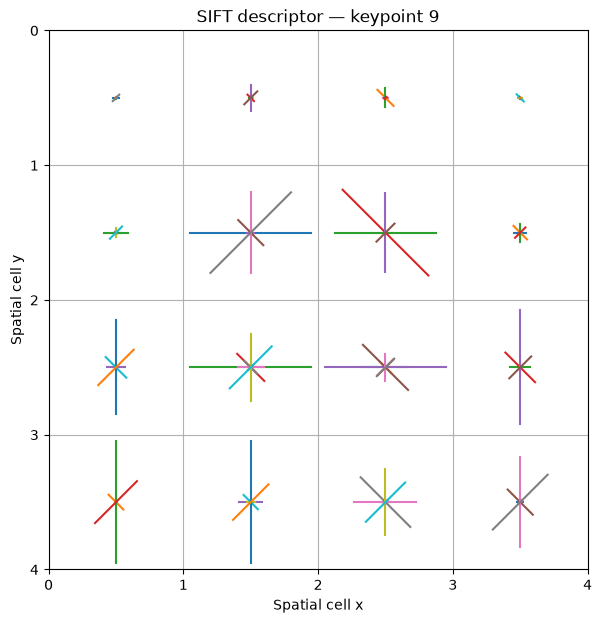

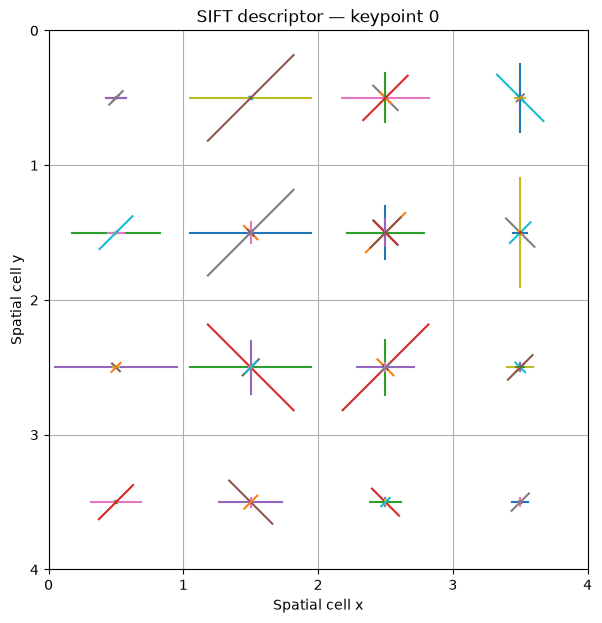

In [11]:
for i, features in enumerate(campus_features):
    index = np.argmax([
        kp.response
        for kp in features.keypoints
    ])

    plot_sift_descriptor(
        features,
        index,
    )

# 2. Descriptor matching

In [ ]:
MATCH_RATIO = 0.5

# Matching from left to anchor image
campus_matches_left_anchor = match_lowe_ratio(
    campus_features[0].descriptors,
    campus_features[1].descriptors,
    ratio=MATCH_RATIO,
)

points_src, points_dst = matched_points(
    campus_features[0].keypoints,
    campus_features[1].keypoints,
    campus_matches_left_anchor,
)

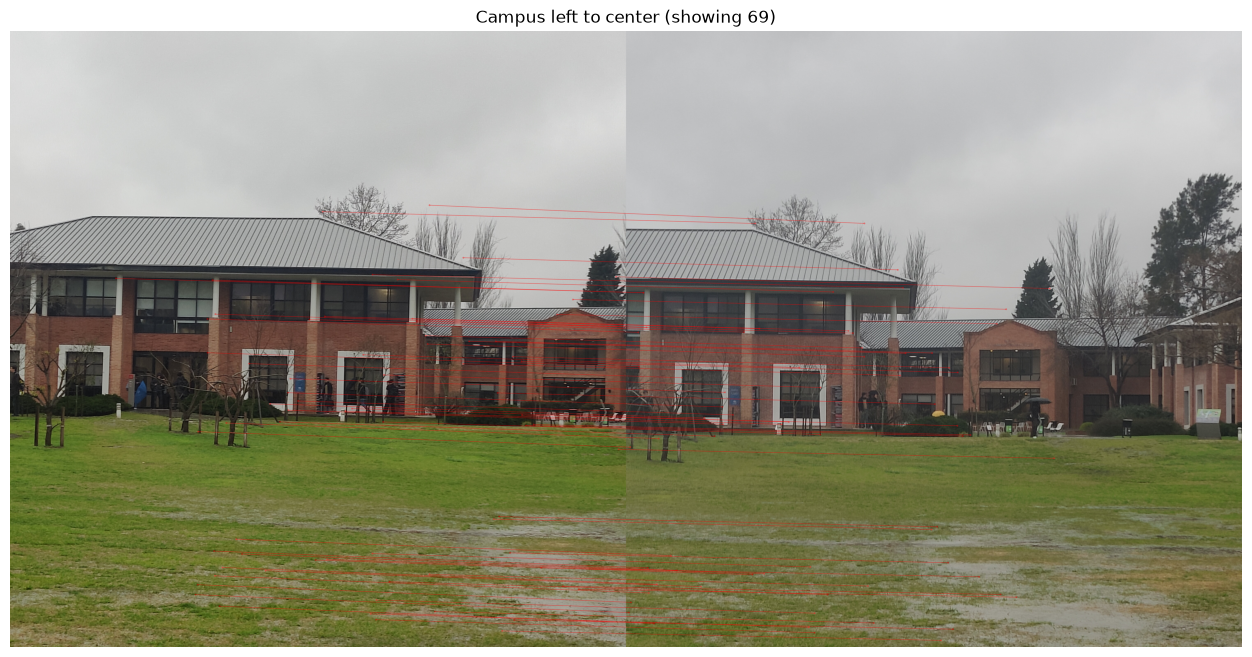

In [30]:
plot_matches(
    campus_images[0],
    campus_images[1],
    campus_features[0].keypoints,
    campus_features[1].keypoints,
    campus_matches_left_anchor,
    max_matches=500,
    title="Campus left to center",
)

In [24]:
RANSAC_THRESHOLD = 5.0
RANSAC_MAX_ITERATIONS = 2000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

campus_ransac_left_anchor = ransac_homography(
    points_src,
    points_dst,
    threshold=RANSAC_THRESHOLD,
    max_iterations=RANSAC_MAX_ITERATIONS,
    rng=rng,
)

inlier_mask = campus_ransac_left_anchor.inlier_mask

inlier_points_src = points_src[inlier_mask]
inlier_points_dst = points_dst[inlier_mask]

inlier_matches = [
    match
    for match, is_inlier in zip(
        campus_matches_left_anchor,
        inlier_mask,
    )
    if is_inlier
]

print(f"Matches: {len(campus_matches_left_anchor)}")
print(f"Inliers: {len(inlier_matches)}")
print(f"Outliers: {len(campus_matches_left_anchor) - len(inlier_matches)}")

inlier_errors = campus_ransac_left_anchor.errors[inlier_mask]

rmse = np.sqrt(np.mean(inlier_errors ** 2))

print(f"RMSE: {rmse:.2f} px")

Matches: 69
Inliers: 62
Outliers: 7
RMSE: 1.46 px


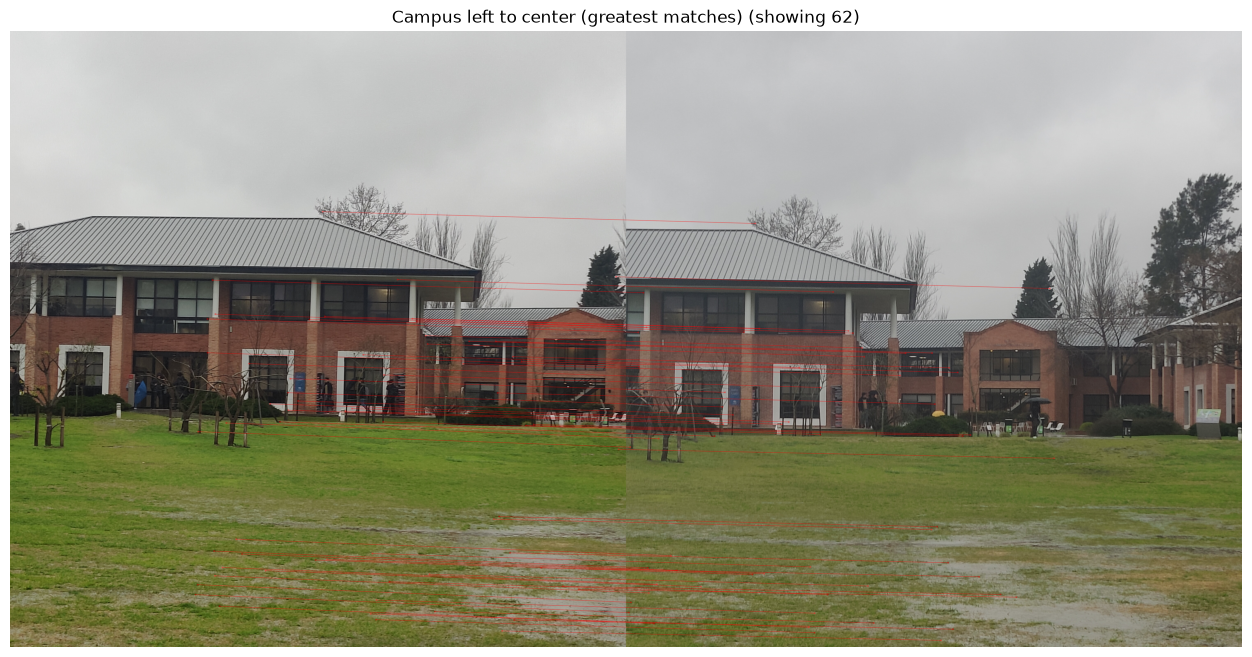

In [ ]:
plot_matches(
    campus_images[0],
    campus_images[1],
    campus_features[0].keypoints,
    campus_features[1].keypoints,
    inlier_matches,
    max_matches=100,
    title="Campus left to center",
)

In [ ]:
# Matching from right to anchor image
campus_matches_right_anchor = match_lowe_ratio(
    campus_features[2].descriptors,
    campus_features[1].descriptors,
    ratio=MATCH_RATIO,
)

points_src, points_dst = matched_points(
    campus_features[2].keypoints,
    campus_features[1].keypoints,
    campus_matches_right_anchor,
)

In [33]:
campus_matches_right_anchor = ransac_homography(
    points_src,
    points_dst,
    threshold=RANSAC_THRESHOLD,
    max_iterations=RANSAC_MAX_ITERATIONS,
    rng=rng,
)

inlier_mask = campus_matches_right_anchor.inlier_mask

inlier_points_src = points_src[inlier_mask]
inlier_points_dst = points_dst[inlier_mask]

inlier_matches = [
    match
    for match, is_inlier in zip(
        campus_matches_left_anchor,
        inlier_mask,
    )
    if is_inlier
]

print(f"Matches: {len(campus_matches_left_anchor)}")
print(f"Inliers: {len(inlier_matches)}")
print(f"Outliers: {len(campus_matches_left_anchor) - len(inlier_matches)}")

inlier_errors = campus_matches_right_anchor.errors[inlier_mask]

rmse = np.sqrt(np.mean(inlier_errors ** 2))

print(f"RMSE: {rmse:.2f} px")

Matches: 69
Inliers: 21
Outliers: 48
RMSE: 2.39 px
